# ImageNet64 FID along the training trajectory

This notebook evaluates saved EMA checkpoints from the ImageNet64 Dawn runs and plots FID against training step for the original Mingyuan/generated-bank runs and the newer constant-LR support matrix. These runs use `PATCH_SIZE = 1`. It deliberately uses an explicit ImageNet64 run allowlist and rejects ImageNet256 configs and reference statistics.

FID is compared at one fixed CFG scale and sample count. Every completed checkpoint evaluation is cached immediately as a JSON file under that run's `fid/` directory, so interrupted runs can be resumed. A consolidated ImageNet64 trajectory JSON is also refreshed after the cached results are loaded.

In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import re
import shlex
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents, start / 'W-Flow']
    for candidate in candidates:
        if (candidate / 'evaluate_checkpoint_fidutil.py').is_file() and (candidate / 'results_dawn').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the W-Flow repository from the current working directory.')


REPO_ROOT = find_repo_root()
RESULTS_ROOT = REPO_ROOT / 'results_dawn'
NOTEBOOK_ROOT = REPO_ROOT / 'notebooks'
EVALUATOR = REPO_ROOT / 'evaluate_checkpoint_fidutil.py'

# Explicit allowlist: no directory is discovered merely because it exists.
RUN_SPECS = {
    'Const-LR Sinkhorn': {
        'base_directory': 'imagenet64_sinkhorn_150k_mingyuan_const',
        'config': 'configs/gen/imagenet64_sinkhorn_150k_mingyuan_const.yaml',
        'patch_sizes': (1,),
    },
    'Drifting (const LR)': {
        'base_directory': 'imagenet64_drifting_150k_mingyuan_const',
        'config': 'configs/gen/imagenet64_drifting_150k_mingyuan_const.yaml',
        'patch_sizes': (1,),
    },
    'Sliced Riesz (fresh support, LR 4e-4)': {
        'base_directory': 'imagenet64_sliced_riesz_fresh_support_lr4e4_mingyuan_const',
        'config': 'configs/gen/imagenet64_sliced_riesz_fresh_support_lr4e4.yaml',
        'patch_sizes': (1,),
    },
    'Direct Riesz (frozen-velocity RMS, LR 4e-4)': {
        'base_directory': 'imagenet64_riesz_frozen_velocity_rms_lr4e4',
        'config': 'configs/gen/imagenet64_riesz_rms_lr4e4.yaml',
        'patch_sizes': (1,),
    },
    'Sliced Riesz (frozen-velocity RMS, LR 4e-4)': {
        'base_directory': 'imagenet64_sliced_riesz_frozen_velocity_rms_lr4e4',
        'config': 'configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml',
        'patch_sizes': (1,),
    },
    'Sliced Riesz (frozen-velocity unit RMS, LR 4e-4)': {
        'base_directory': 'imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4',
        'config': 'configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml',
        'patch_sizes': (1,),
    },
    'Matern-3/2 (multiscale frozen-velocity RMS, LR 4e-4)': {
        'base_directory': 'imagenet64_matern32_frozen_velocity_rms_multiscale_lr4e4',
        'config': 'configs/gen/imagenet64_matern32_rms_lr4e4.yaml',
        'patch_sizes': (1,),
    },
}

print(f'Repository:   {REPO_ROOT}')
print(f'Results root: {RESULTS_ROOT}')
print(f'Python:       {sys.executable}')

Repository:   /home/zongchen/mmd_flow_hudson/W-Flow
Results root: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn
Python:       /home/zongchen/miniconda3/envs/mmd_flow_hudson/bin/python


## Evaluation controls

All active ImageNet64 runs use `PATCH_SIZE = 1`. The default trajectory uses only exact multiples of 10,000 training steps, FID-50K, and CFG 2.5. Set `RUN_EVALUATION = True` when the notebook is running on a GPU node. Change `STEP_INTERVAL` if a different regular evaluation interval is needed.

In [2]:
PATCH_SIZE = 1  # All active runs use *_ps_1 directories.
CFG_SCALE = 2.5
NUM_SAMPLES = 50_000
GEN_BSZ_PER_GPU = 64
SEED = 0
NPROC_PER_NODE = 1
MASTER_PORT = 6671

STEP_INTERVAL = 10_000
MIN_STEP = None
MAX_STEP = None
RUN_EVALUATION = True
KEEP_SAMPLES = False

if PATCH_SIZE not in (1, 2):
    raise ValueError('PATCH_SIZE must be 1 or 2.')
PATCH_TAG = f'ps{PATCH_SIZE}'
RUN_DIRECTORY_SUFFIX = '_ps_1' if PATCH_SIZE == 1 else ''

if NUM_SAMPLES <= 0 or NUM_SAMPLES % 1000 != 0:
    raise ValueError('NUM_SAMPLES must be positive and divisible by 1000 classes.')
if GEN_BSZ_PER_GPU <= 0 or NPROC_PER_NODE <= 0 or STEP_INTERVAL <= 0:
    raise ValueError('Batch size, process count, and step interval must be positive.')
if not math.isfinite(CFG_SCALE) or CFG_SCALE <= 0:
    raise ValueError('CFG_SCALE must be finite and positive.')

In [3]:
CHECKPOINT_PATTERN = re.compile(r'^state_(\d+)\.pt$')
records = []

config_dir = RESULTS_ROOT / 'fid_configs'
config_dir.mkdir(parents=True, exist_ok=True)

active_run_specs = {
    run_name: spec for run_name, spec in RUN_SPECS.items()
    if PATCH_SIZE in spec.get('patch_sizes', (1, 2))
}

for run_name, spec in active_run_specs.items():
    run_dir = (RESULTS_ROOT / f"{spec['base_directory']}{RUN_DIRECTORY_SUFFIX}").resolve()
    source_config_path = (REPO_ROOT / spec['config']).resolve()
    config_path = (config_dir / f'{source_config_path.stem}_{PATCH_TAG}.yaml').resolve()

    if 'imagenet256' in run_dir.name.lower() or 'imagenet256' in source_config_path.name.lower():
        raise ValueError(f'ImageNet256 path rejected: {run_dir} / {source_config_path}')
    if not run_dir.is_dir():
        raise FileNotFoundError(f'Missing run directory: {run_dir}')
    if source_config_path.is_file():
        config_data = yaml.safe_load(source_config_path.read_text(encoding='utf-8'))
    elif config_path.is_file():
        # Preserve the exact evaluation snapshot for a completed historical
        # run when its training config has since been removed from the repo.
        config_data = yaml.safe_load(config_path.read_text(encoding='utf-8'))
    else:
        raise FileNotFoundError(
            f'Missing both source config and evaluation snapshot: '
            f'{source_config_path} / {config_path}'
        )

    resolution = int(config_data['dataset']['resolution'])
    num_classes = int(config_data['dataset']['num_classes'])
    if resolution != 64 or num_classes != 1000:
        raise ValueError(f'{run_name} is not ImageNet64/1K: resolution={resolution}, classes={num_classes}')
    config_data['model']['patch_size'] = PATCH_SIZE
    config_text = yaml.safe_dump(config_data, sort_keys=False)
    if not config_path.is_file() or config_path.read_text(encoding='utf-8') != config_text:
        temporary_config_path = config_path.with_name(f'.{config_path.name}.{os.getpid()}.tmp')
        temporary_config_path.write_text(config_text, encoding='utf-8')
        os.replace(temporary_config_path, config_path)

    checkpoints = []
    for checkpoint in (run_dir / 'checkpoints').glob('state_*.pt'):
        match = CHECKPOINT_PATTERN.fullmatch(checkpoint.name)
        if match:
            checkpoints.append((int(match.group(1)), checkpoint.resolve()))
    checkpoints.sort()
    if not checkpoints:
        print(f"No saved checkpoints yet for {run_name}; skipping {run_dir / 'checkpoints'}")
        continue

    for step, checkpoint in checkpoints:
        if MIN_STEP is not None and step < MIN_STEP:
            continue
        if MAX_STEP is not None and step > MAX_STEP:
            continue
        records.append({
            'run': run_name,
            'step': step,
            'checkpoint': checkpoint,
            'run_dir': run_dir,
            'config': config_path,
        })

all_checkpoints = sorted(records, key=lambda row: (row['run'], row['step']))
if not all_checkpoints:
    raise RuntimeError('No checkpoints remain after applying MIN_STEP and MAX_STEP.')

selected_checkpoints = [
    row for row in all_checkpoints if row['step'] % STEP_INTERVAL == 0
]
if not selected_checkpoints:
    raise RuntimeError(f'No checkpoints selected for STEP_INTERVAL={STEP_INTERVAL}.')

print(f'{"Run":<20} {"Checkpoints":>11} {"First step":>12} {"Last step":>11}')
for run_name in active_run_specs:
    steps = [row['step'] for row in selected_checkpoints if row['run'] == run_name]
    if steps:
        print(f'{run_name:<20} {len(steps):>11} {min(steps):>12} {max(steps):>11}')
    else:
        print(f'{run_name:<20} {0:>11} {"-":>12} {"-":>11}')
print(f'Patch size: {PATCH_SIZE} ({PATCH_TAG})')
print(f'Selected {len(selected_checkpoints)} of {len(all_checkpoints)} saved ImageNet64 checkpoints at exact {STEP_INTERVAL:,}-step intervals.')

Run                  Checkpoints   First step   Last step
Const-LR Sinkhorn              8        10000      100000
Drifting (const LR)            3        10000       30000
Sliced Riesz (fresh support, LR 4e-4)           4        10000       40000
Direct Riesz (frozen-velocity RMS, LR 4e-4)          13        10000      130000
Sliced Riesz (frozen-velocity RMS, LR 4e-4)           8        10000       80000
Sliced Riesz (frozen-velocity unit RMS, LR 4e-4)           7        10000       70000
Matern-3/2 (multiscale frozen-velocity RMS, LR 4e-4)           2        10000       20000
Patch size: 1 (ps1)
Selected 45 of 97 saved ImageNet64 checkpoints at exact 10,000-step intervals.


In [4]:
def resolve_imagenet64_fid_reference() -> Path:
    candidates = []
    if os.environ.get('IMAGENET64_FID_NPZ'):
        candidates.append(Path(os.environ['IMAGENET64_FID_NPZ']).expanduser())
    if os.environ.get('WFLOW_HF_ROOT'):
        candidates.append(Path(os.environ['WFLOW_HF_ROOT']).expanduser() / 'stats' / 'VIRTUAL_imagenet64_labeled.npz')
    if os.environ.get('WFLOW_CACHE_ROOT'):
        candidates.append(Path(os.environ['WFLOW_CACHE_ROOT']).expanduser() / 'wflow_hf_root' / 'stats' / 'VIRTUAL_imagenet64_labeled.npz')
    candidates.append(REPO_ROOT / '.cache' / 'wflow_hf_root' / 'stats' / 'VIRTUAL_imagenet64_labeled.npz')

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return candidates[0].resolve()


FID_REFERENCE = resolve_imagenet64_fid_reference()
if 'in256' in FID_REFERENCE.name.lower() or FID_REFERENCE.name == 'jit_in256_stats.npz':
    raise ValueError(f'ImageNet256 FID statistics rejected: {FID_REFERENCE}')

print(f'ImageNet64 FID reference: {FID_REFERENCE}')
print(f'Reference exists:         {FID_REFERENCE.is_file()}')
print(f'Run evaluation:           {RUN_EVALUATION}')

ImageNet64 FID reference: /home/zongchen/mmd_flow_hudson/W-Flow/.cache/wflow_hf_root/stats/VIRTUAL_imagenet64_labeled.npz
Reference exists:         True
Run evaluation:           True


## Evaluate selected checkpoints

Each command loads the checkpoint's EMA model, generates class-balanced ImageNet64 samples, computes FID against `VIRTUAL_imagenet64_labeled.npz`, and immediately writes a checkpoint-specific JSON record such as `<run>/fid/fid50k_step00025000_cfg2.5.json`. The evaluator checks that the step stored inside a checkpoint agrees with its filename. Existing valid results for the exact checkpoint, CFG, sample count, seed, and reference file are skipped. When training creates later checkpoints, rerun the discovery and evaluation cells: cached steps will be skipped and only new steps will be computed.

In [5]:
if not RUN_EVALUATION:
    print('Dry run only. Set RUN_EVALUATION = True in the controls cell to compute missing FIDs.')
else:
    accelerator_available = torch.cuda.is_available() or (hasattr(torch, 'xpu') and torch.xpu.is_available())
    if not accelerator_available:
        raise RuntimeError('RUN_EVALUATION=True requires a visible CUDA or Intel XPU accelerator.')
    if not FID_REFERENCE.is_file():
        raise FileNotFoundError(
            f'Missing ImageNet64 FID statistics: {FID_REFERENCE}\n'
            'Set IMAGENET64_FID_NPZ or WFLOW_HF_ROOT to the correct Dawn cache location.'
        )
    with np.load(FID_REFERENCE) as reference_data:
        if not {'mu', 'sigma'}.issubset(reference_data.files):
            raise ValueError(f'FID reference lacks mu/sigma arrays: {FID_REFERENCE}')
        mu = reference_data['mu']
        sigma = reference_data['sigma']
        if mu.ndim != 1 or sigma.shape != (mu.size, mu.size):
            raise ValueError(f'Invalid FID reference shapes: mu={mu.shape}, sigma={sigma.shape}')

    eval_env = os.environ.copy()
    eval_env['IMAGENET64_FID_NPZ'] = str(FID_REFERENCE)
    eval_env['PYTHONUNBUFFERED'] = '1'

    for index, row in enumerate(selected_checkpoints):
        if NPROC_PER_NODE == 1:
            command = [sys.executable]
        else:
            command = [
                sys.executable, '-m', 'torch.distributed.run',
                '--standalone', '--nnodes=1',
                f'--nproc_per_node={NPROC_PER_NODE}',
                f'--master_port={MASTER_PORT}',
            ]
        command += [
            str(EVALUATOR),
            '--run-dir', str(row['run_dir']),
            '--ckpt', str(row['checkpoint']),
            '--config', str(row['config']),
            '--cfg-scales', f'{CFG_SCALE:g}',
            '--num-samples', str(NUM_SAMPLES),
            '--gen-bsz', str(GEN_BSZ_PER_GPU),
            '--seed', str(SEED),
            '--fid-ref', str(FID_REFERENCE),
            '--result-dir', str(row['run_dir'] / 'fid'),
            '--skip-existing',
        ]
        if KEEP_SAMPLES:
            command.append('--keep-samples')

        print(f'\n[{index + 1}/{len(selected_checkpoints)}] {row["run"]}, step {row["step"]}')
        print(shlex.join(command))
        subprocess.run(command, cwd=REPO_ROOT, env=eval_env, check=True)


[1/45] Const-LR Sinkhorn, step 10000
/home/zongchen/miniconda3/envs/mmd_flow_hudson/bin/python /home/zongchen/mmd_flow_hudson/W-Flow/evaluate_checkpoint_fidutil.py --run-dir /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1 --ckpt /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/checkpoints/state_00010000.pt --config /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/fid_configs/imagenet64_sinkhorn_150k_mingyuan_const_ps1.yaml --cfg-scales 2.5 --num-samples 50000 --gen-bsz 64 --seed 0 --fid-ref /home/zongchen/mmd_flow_hudson/W-Flow/.cache/wflow_hf_root/stats/VIRTUAL_imagenet64_labeled.npz --result-dir /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/fid --skip-existing


Config:       /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/fid_configs/imagenet64_sinkhorn_150k_mingyuan_const_ps1.yaml
Resolution:   64
Checkpoint:   /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/checkpoints/state_00010000.pt
Reference:    /home/zongchen/mmd_flow_hudson/W-Flow/.cache/wflow_hf_root/stats/VIRTUAL_imagenet64_labeled.npz
CFG scales:   [2.5]
Samples/CFG:  50000
Result dir:   /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/fid
Work root:    /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/fid/work


/home/zongchen/mmd_flow_hudson/W-Flow/inference_ours.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loaded EMA model from step 10000 (/home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/checkpoints/state_00010000.pt)
  Parameters: 25,254,916
Skipping completed result: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/fid/fid50k_step00010000_cfg2.5.json
Saved summary: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sinkhorn_150k_mingyuan_const_ps_1/fid/fid50k_step00010000_summary.json
Best FID: 37.722876 at CFG 2.5


...


[45/45] Sliced Riesz (frozen-velocity unit RMS, LR 4e-4), step 70000
/home/zongchen/miniconda3/envs/mmd_flow_hudson/bin/python /home/zongchen/mmd_flow_hudson/W-Flow/evaluate_checkpoint_fidutil.py --run-dir /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1 --ckpt /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/checkpoints/state_00070000.pt --config /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/fid_configs/imagenet64_sliced_riesz_rms_lr4e4_ps1.yaml --cfg-scales 2.5 --num-samples 50000 --gen-bsz 64 --seed 0 --fid-ref /home/zongchen/mmd_flow_hudson/W-Flow/.cache/wflow_hf_root/stats/VIRTUAL_imagenet64_labeled.npz --result-dir /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/fid --skip-existing


Config:       /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/fid_configs/imagenet64_sliced_riesz_rms_lr4e4_ps1.yaml
Resolution:   64
Checkpoint:   /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/checkpoints/state_00070000.pt
Reference:    /home/zongchen/mmd_flow_hudson/W-Flow/.cache/wflow_hf_root/stats/VIRTUAL_imagenet64_labeled.npz
CFG scales:   [2.5]
Samples/CFG:  50000
Result dir:   /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/fid
Work root:    /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/fid/work


/home/zongchen/mmd_flow_hudson/W-Flow/inference_ours.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loaded EMA model from step 70000 (/home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/checkpoints/state_00070000.pt)
  Parameters: 25,254,916
Skipping completed result: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/fid/fid50k_step00070000_cfg2.5.json
Saved summary: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1/fid/fid50k_step00070000_summary.json
Best FID: 29.635988 at CFG 2.5


## Load, validate, and plot trajectory results

Only finite FID records matching a selected ImageNet64 checkpoint, the current CFG scale, and the current sample count are plotted. Selection covers only exact `STEP_INTERVAL` multiples. This also lets the plotting cells be rerun while evaluations are still accumulating; unrelated off-grid JSON results remain saved but are excluded.

In [6]:
cfg_text = f'{CFG_SCALE:g}'
sample_text = f'fid{NUM_SAMPLES // 1000}k'
result_records = []

for row in selected_checkpoints:
    result_path = row['run_dir'] / 'fid' / f'{sample_text}_step{row["step"]:08d}_cfg{cfg_text}.json'
    if not result_path.is_file():
        continue
    try:
        payload = json.loads(result_path.read_text(encoding='utf-8'))
        payload_checkpoint = Path(payload['ckpt']).expanduser().resolve()
        valid = (
            int(payload['resolution']) == 64
            and int(payload['step']) == int(row['step'])
            and payload_checkpoint == row['checkpoint']
            and int(payload['num_samples']) == NUM_SAMPLES
            and int(payload['seed']) == SEED
            and math.isclose(float(payload['cfg_scale']), CFG_SCALE, rel_tol=0.0, abs_tol=1e-12)
            and Path(payload['fid_ref']).expanduser().resolve() == FID_REFERENCE
            and math.isfinite(float(payload['fid']))
        )
    except (KeyError, TypeError, ValueError, json.JSONDecodeError):
        valid = False
    if valid:
        result_records.append({
            'run': row['run'],
            'patch_size': PATCH_SIZE,
            'step': int(row['step']),
            'fid': float(payload['fid']),
            'cfg_scale': float(payload['cfg_scale']),
            'num_samples': int(payload['num_samples']),
            'checkpoint': str(row['checkpoint']),
            'result_json': str(result_path),
        })

trajectory = sorted(result_records, key=lambda row: (row['run'], row['step']))
if not trajectory:
    print('No matching trajectory FID results yet. Run the evaluation cell first.')
else:
    trajectory_json_path = NOTEBOOK_ROOT / f'imagenet64_fid{NUM_SAMPLES // 1000}k_cfg{cfg_text}_{PATCH_TAG}_trajectory.json'
    trajectory_payload = {
        'schema_version': 1,
        'dataset': 'ImageNet64',
        'resolution': 64,
        'patch_size': PATCH_SIZE,
        'cfg_scale': CFG_SCALE,
        'num_samples': NUM_SAMPLES,
        'seed': SEED,
        'step_interval': STEP_INTERVAL,
        'fid_reference': str(FID_REFERENCE),
        'updated_at_utc': datetime.now(timezone.utc).isoformat(),
        'results': trajectory,
    }
    temporary_json_path = trajectory_json_path.with_name(f'.{trajectory_json_path.name}.{os.getpid()}.tmp')
    temporary_json_path.write_text(json.dumps(trajectory_payload, indent=2) + '\n', encoding='utf-8')
    os.replace(temporary_json_path, trajectory_json_path)
    print(f'Saved consolidated JSON: {trajectory_json_path}')

    print(f'{"Run":<20} {"Step":>10} {"FID":>12}')
    for row in trajectory:
        print(f'{row["run"]:<20} {row["step"]:>10} {row["fid"]:>12.6f}')
    print('\nBest checkpoint per run:')
    best_rows = []
    for run_name in active_run_specs:
        run_rows = [row for row in trajectory if row['run'] == run_name]
        if run_rows:
            best_rows.append(min(run_rows, key=lambda row: row['fid']))
    for row in sorted(best_rows, key=lambda row: row['fid']):
        print(f'{row["run"]:<20} step={row["step"]:>8}, FID={row["fid"]:.6f}')

Saved consolidated JSON: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_fid50k_cfg2.5_ps1_trajectory.json
Run                        Step          FID
Const-LR Sinkhorn         10000    37.722876
Const-LR Sinkhorn         20000    31.244123
Const-LR Sinkhorn         30000    28.338009
Const-LR Sinkhorn         60000    25.376703
Const-LR Sinkhorn         70000    24.910567
Const-LR Sinkhorn         80000    24.500757
Const-LR Sinkhorn         90000    24.171539
Const-LR Sinkhorn        100000    23.720759
Direct Riesz (frozen-velocity RMS, LR 4e-4)      10000    37.907059
Direct Riesz (frozen-velocity RMS, LR 4e-4)      20000    33.293040
Direct Riesz (frozen-velocity RMS, LR 4e-4)      30000    31.418088
Direct Riesz (frozen-velocity RMS, LR 4e-4)      40000    30.712859
Direct Riesz (frozen-velocity RMS, LR 4e-4)      50000    29.891177
Direct Riesz (frozen-velocity RMS, LR 4e-4)      60000    29.639697
Direct Riesz (frozen-velocity RMS, LR 4e-4)      70000    29.12915

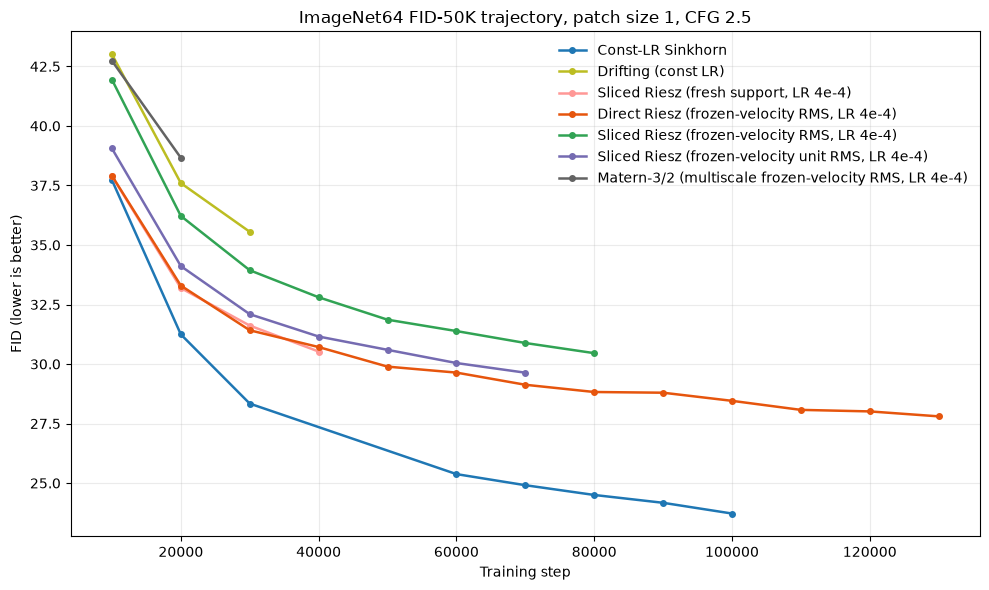

Saved figure: /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_fid50k_cfg2.5_ps1_trajectory.png
Saved table:  /home/zongchen/mmd_flow_hudson/W-Flow/results_dawn/imagenet64_fid50k_cfg2.5_ps1_trajectory.csv


In [7]:
if trajectory:
    colors = {
        'Mingyuan Sinkhorn': '#9467bd',
        'Mingyuan Direct Riesz': '#ff7f0e',
        'Generated-bank Riesz': '#8c564b',
        'Const-LR Sinkhorn': '#1f77b4',
        'Direct Riesz (saved support)': '#17becf',
        'Sliced Riesz (saved support)': '#e377c2',
        'Drifting (const LR)': '#bcbd22',
        'Sliced Riesz (fresh support, LR 4e-4)': '#ff9896',
        'Direct Riesz (frozen-velocity RMS, LR 4e-4)': '#e6550d',
        'Sliced Riesz (frozen-velocity RMS, LR 4e-4)': '#31a354',
        'Sliced Riesz (frozen-velocity unit RMS, LR 4e-4)': '#756bb1',
        'Matern-3/2 (multiscale frozen-velocity RMS, LR 4e-4)': '#636363',
    }
    fig, ax = plt.subplots(figsize=(10, 6))
    for run_name in active_run_specs:
        run_data = [row for row in trajectory if row['run'] == run_name]
        if not run_data:
            continue
        ax.plot(
            [row['step'] for row in run_data], [row['fid'] for row in run_data],
            marker='o', markersize=4, linewidth=1.8,
            color=colors[run_name], label=run_name,
        )

    ax.set_title(f'ImageNet64 FID-{NUM_SAMPLES // 1000}K trajectory, patch size {PATCH_SIZE}, CFG {CFG_SCALE:g}')
    ax.set_xlabel('Training step')
    ax.set_ylabel('FID (lower is better)')
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    figure_path = NOTEBOOK_ROOT / f'imagenet64_fid{NUM_SAMPLES // 1000}k_cfg{cfg_text}_{PATCH_TAG}_trajectory.png'
    table_path = NOTEBOOK_ROOT / f'imagenet64_fid{NUM_SAMPLES // 1000}k_cfg{cfg_text}_{PATCH_TAG}_trajectory.csv'
    fig.savefig(figure_path, dpi=180, bbox_inches='tight')
    with table_path.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(trajectory[0]))
        writer.writeheader()
        writer.writerows(trajectory)
    plt.show()
    print(f'Saved figure: {figure_path}')
    print(f'Saved table:  {table_path}')